In [5]:
import obspy
import os

# 1. ИСПРАВЛЕНИЕ: Добавлена буква 'r' перед строкой (raw string).
# Без нее Python может воспринять "\V" как специальный символ и выдать ошибку пути.
# Альтернатива: использовать прямые слеши "data/Vp_zoloto_50sm-50sm_MODEL.sgy"
file_path = r"data\Vp_zoloto_50sm-50sm_MODEL.sgy"

# 2. Проверка существования файла перед чтением
if not os.path.exists(file_path):
    print(f"❌ Ошибка: Файл не найден по пути: {file_path}")
    print("Проверьте текущую рабочую директорию и правильность имени файла.")
else:
    try:
        # Читаем файл
        print(f"Читаю файл: {file_path} ...")
        stream = obspy.read(file_path, format="SEGY")
        print(f"✅ Успешно прочитано. Количество трасс: {len(stream)}")
        
        # Получаем заголовок первой трассы
        header = stream[0].stats.segy.trace_header
        
        print("\n" + "="*50)
        print("ПОЛНЫЙ ОБЪЕКТ ЗАГОЛОВКА ТРАССЫ:")
        print("="*50)
        print(header)
        
        # 3. ПОЛЕЗНОЕ ДОПОЛНЕНИЕ: Сразу проверяем самые важные поля, 
        # о которых говорится в README (inline, crossline, координаты)
        print("\n" + "="*50)
        print("ПРОВЕРКА КЛЮЧЕВЫХ ПОЛЕЙ (возможные места хранения координат):")
        print("="*50)
        print(f"inline_number (обычно байты 193-196): {header.inline_number}")
        print(f"crossline_number (обычно байты 197-200): {header.crossline_number}")
        print(f"cdp_x (координата X, байты 73-76): {header.cdp_x}")
        print(f"cdp_y (координата Y, байты 77-80): {header.cdp_y}")
        print(f"field_record (байты 9-12): {header.field_record}")
        
    except Exception as e:
        print(f"❌ Ошибка при чтении файла SEGY: {e}")

Читаю файл: data\Vp_zoloto_50sm-50sm_MODEL.sgy ...
✅ Успешно прочитано. Количество трасс: 4001

ПОЛНЫЙ ОБЪЕКТ ЗАГОЛОВКА ТРАССЫ:
LazyTraceHeaderAttribDict({'unpacked_header': b'\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x01\x00\x01\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\xea`\x00\x00\xea`\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\x9c\xff\x9c\x00\x11\xe6\x08\x002\x14P\x00\x11\xe6\x08\x002\x14P\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xfd\xa8\x00\x00\x00\x00\x03!\x01\xf4\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00-\xd2\x00\x00\x804\x00\x00\x00\x01\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

Читаю файл: data\Vp_zoloto_50sm-50sm_MODEL.sgy ...
✅ Успешно прочитано.
📊 Количество трасс: 4001
📊 Количество отсчетов в трассе: 801
✅ Данные успешно загружены в NumPy массив формы: (4001, 801)
✅ Визуализация сохранена в файл: vp_model_visualization.png


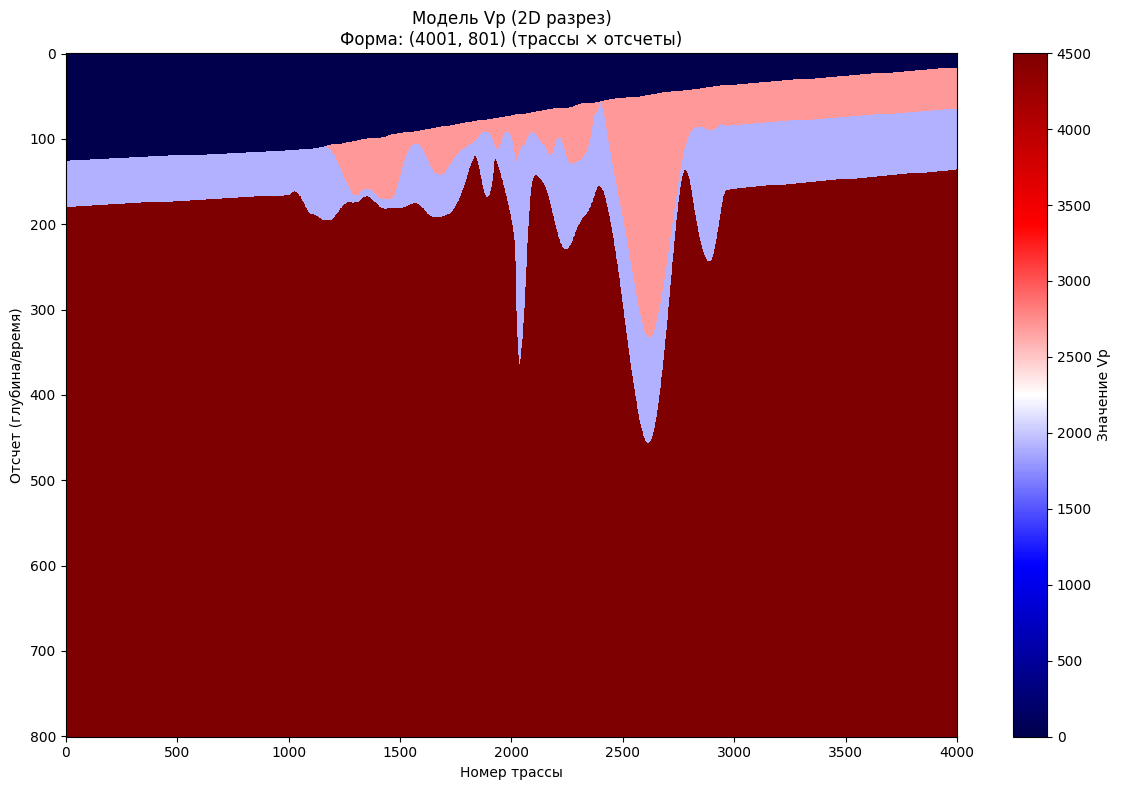

✅ Данные сохранены в файл: vp_model.npy


In [7]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
import os

file_path = r"data\Vp_zoloto_50sm-50sm_MODEL.sgy"

if not os.path.exists(file_path):
    print(f"❌ Файл не найден: {file_path}")
else:
    print(f"Читаю файл: {file_path} ...")
    stream = obspy.read(file_path, format="SEGY")
    
    num_traces = len(stream)
    num_samples = len(stream[0].data)
    print(f"✅ Успешно прочитано.")
    print(f"📊 Количество трасс: {num_traces}")
    print(f"📊 Количество отсчетов в трассе: {num_samples}")
    
    # 1. Извлекаем данные из всех трасс в один 2D NumPy массив
    # Форма массива будет (num_traces, num_samples)
    seismic_data = np.zeros((num_traces, num_samples), dtype=np.float32)
    for i, trace in enumerate(stream):
        seismic_data[i, :] = trace.data
    
    print(f"✅ Данные успешно загружены в NumPy массив формы: {seismic_data.shape}")
    
    # 2. Визуализируем результат, чтобы понять, что внутри
    plt.figure(figsize=(12, 8))
    
    # Вариант А: Если это 2D разрез (например, вертикальный разрез скорости)
    # Отображаем как изображение (трассы по X, глубина/время по Y)
    plt.imshow(seismic_data.T, aspect='auto', cmap='seismic', interpolation='nearest')
    plt.title(f"Модель Vp (2D разрез)\nФорма: {seismic_data.shape} (трассы × отсчеты)")
    plt.xlabel("Номер трассы")
    plt.ylabel("Отсчет (глубина/время)")
    plt.colorbar(label="Значение Vp")
    plt.tight_layout()
    plt.savefig("vp_model_visualization.png", dpi=150)
    print("✅ Визуализация сохранена в файл: vp_model_visualization.png")
    plt.show()
    
    # 3. Сохраняем в формат .npy для дальнейшего использования в PINN/Diffusion
    np.save("vp_model.npy", seismic_data)
    print("✅ Данные сохранены в файл: vp_model.npy")